# 🎙️ Hinglish ASR: Whisper + LoRA + Optuna Hyperparameter Search

**Dataset:** `ujs/hinglish-compressed` — 56k samples of technical Hinglish (Devanagari + English)

## 📋 Notebook Plan
| Phase | Task |
|---|---|
| **Phase 1A** | Load `openai/whisper-medium` → Evaluate WER & CER on 10 test samples |
| **Phase 1B** | Load `collabora/whisper-medium-hindi` → Evaluate WER & CER on same 10 samples |
| **Phase 1C** | Baseline `openai/whisper-medium` WER/CER on 100 test samples |
| **Phase 2** | 🔬 **Optuna HPO** — TPE sampler · Median pruner · 6 trials × 150 steps × 500 samples |
| **Phase 3** | ✅ Final fine-tune with **best Optuna params** on 3000 samples × 500 steps |
| **Phase 4** | Evaluate fine-tuned model on 10 + 100 samples → Compare all results |

**Hardware:** Kaggle P100 / T4  
**Optuna strategy:** TPE sampler · Median pruner · minimise WER on 50 val samples  
**Target:** WER ≤ 30%

## ⚙️ Step 0: Install Dependencies

In [1]:
%%capture
!pip install transformers==4.40.0
!pip install datasets==2.19.0
!pip install evaluate==0.4.2
!pip install jiwer==3.0.4
!pip install peft==0.10.0
!pip install accelerate==0.29.3
!pip install librosa==0.10.1
!pip install soundfile
!pip install torchaudio
!pip install optuna==3.6.1
!pip install optuna-integration
print('✅ All packages installed successfully!')

## 📦 Step 1: Imports & GPU Check

In [2]:
import torch
import numpy as np
import pandas as pd
import warnings
import gc
import os
import json
import time
warnings.filterwarnings('ignore')

from datasets import load_dataset, Audio
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    WhisperFeatureExtractor,
    WhisperTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    pipeline,
    get_linear_schedule_with_warmup,
    get_cosine_schedule_with_warmup,
    get_cosine_with_hard_restarts_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import evaluate
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from torch.optim import AdamW
from torch.utils.data import DataLoader

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── GPU Check ──────────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.float16 if torch.cuda.is_available() else torch.float32

print(f"🖥️  Device  : {device.upper()}")
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"🎮 GPU     : {gpu.name}")
    print(f"💾 VRAM    : {gpu.total_memory / 1e9:.1f} GB")
print(f"🔢 PyTorch : {torch.__version__}")
print(f"🧪 Optuna  : {optuna.__version__}")

2026-03-13 07:22:27.477382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773386547.667206      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773386547.724611      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773386548.190889      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773386548.190935      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773386548.190938      24 computation_placer.cc:177] computation placer alr

🖥️  Device  : CUDA
🎮 GPU     : Tesla T4
💾 VRAM    : 15.6 GB
🔢 PyTorch : 2.9.0+cu126
🧪 Optuna  : 3.6.1


## 📂 Step 2: Load Dataset & Fix Test Samples

In [3]:
print("📥 Loading ujs/hinglish-compressed dataset...")
dataset = load_dataset("ujs/hinglish-compressed", trust_remote_code=True)
print(f"✅ Dataset loaded: {dataset}")

# Resample all audio to 16kHz (required by Whisper)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))
print("✅ Audio resampled to 16kHz")

# ── Fix the SAME 10 test samples for ALL evaluations ─────────────────────────
TEST_INDICES = list(range(10))
test_samples = [dataset["test"][i] for i in TEST_INDICES]

print("\n📋 The 10 Fixed Test Samples (Reference Transcriptions):")
print("-" * 70)
for i, s in enumerate(test_samples):
    print(f"[{i:02d}] {s['sentence'][:80]}")

REFERENCES = [s['sentence'] for s in test_samples]

📥 Loading ujs/hinglish-compressed dataset...


Generating train split:   0%|          | 0/52825 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3136 [00:00<?, ? examples/s]

✅ Dataset loaded: DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'sentence'],
        num_rows: 52825
    })
    test: Dataset({
        features: ['path', 'audio', 'sentence'],
        num_rows: 3136
    })
})
✅ Audio resampled to 16kHz

📋 The 10 Fixed Test Samples (Reference Transcriptions):
----------------------------------------------------------------------
[00] लिबर ऑफिस impress में एक प्रस्तुति document बनाना और बुनियादी formatting के इस s
[01] इस tutorial में हम impress window के भागों के बारे में सीखेंगे और कैसे स्लाइड इन
[02] यहाँ हम अपने ऑपरेटिंग सिस्टम के रूप में gnu/linux और लिबरऑफिस वर्जन 334 का उपयोग
[03] चलिए अपनी प्रस्तुति प्रेजैटेशन sample impress open करते हैं जिसे पिछले tutorial 
[04] चलिए देखते हैं कि screen पर क्या क्या है
[05] मध्य में हम खाली जगह देखते है जोकि workspace है जहाँ हम काम करेंगे
[06] जैसे कि आप देख सकते हैं workspace में 5 tabs हैं जिन्हें view buttons कहते हैं
[07] फिलहाल normal टैब चुनित हैं
[08] यह मुख्य view है अलगअलग sl

## 🛠️ Helper: WER/CER Calculator & Inference Utils

In [4]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

# ── Repetition penalty — applied to EVERY generate() call in this notebook ────
# repetition_penalty=1.2 : penalises tokens that already appeared in the output.
#   Value > 1.0 reduces repetition; 1.2 is a safe sweet-spot for ASR —
#   strong enough to stop looping hallucinations without distorting fluent speech.
# no_repeat_ngram_size=3 : hard-blocks any 3-gram from being generated twice.
#   Prevents the classic Whisper "hallucination loop" on silent/noisy segments.
#   Size=3 targets phrase-level repetition (bi-grams are too aggressive for Hindi).
GEN_KWARGS = {
    "language"             : "hi",
    "task"                 : "transcribe",
    "max_new_tokens"       : 225,
    "repetition_penalty"   : 1.2,   # penalise already-seen tokens
    "no_repeat_ngram_size" : 3,     # hard-block repeated 3-grams
    "num_beams"            : 5,
    "length_penalty"       : 0.6,
    "early_stopping"       : True,
}
print(f"\U0001f527 GEN_KWARGS: {GEN_KWARGS}")


def compute_metrics_from_lists(predictions, references):
    """Compute WER and CER given prediction and reference lists."""
    preds_clean = [p.strip() for p in predictions]
    refs_clean  = [r.strip() for r in references]
    wer = wer_metric.compute(predictions=preds_clean, references=refs_clean)
    cer = cer_metric.compute(predictions=preds_clean, references=refs_clean)
    return round(wer * 100, 2), round(cer * 100, 2)


def transcribe_samples(pipe_or_model, samples, processor=None, use_pipeline=True):
    """
    Transcribe audio samples using a pipeline or model+processor directly.
    GEN_KWARGS (repetition_penalty=1.2, no_repeat_ngram_size=3) applied to
    all model.generate() calls to suppress hallucination loops.
    """
    predictions = []
    for sample in samples:
        audio_array = sample["audio"]["array"].astype(np.float32)
        if use_pipeline:
            result = pipe_or_model(audio_array)
            predictions.append(result["text"])
        else:
            inputs = processor.feature_extractor(
                audio_array, sampling_rate=16000, return_tensors="pt"
            ).input_features.to(device).to(dtype)
            with torch.no_grad():
                predicted_ids = pipe_or_model.generate(inputs=inputs, **GEN_KWARGS)
            text = processor.tokenizer.batch_decode(
                predicted_ids, skip_special_tokens=True
            )[0]
            predictions.append(text)
    return predictions


def print_results_table(model_name, predictions, references):
    """Print a side-by-side comparison table and return WER, CER."""
    wer, cer = compute_metrics_from_lists(predictions, references)
    print(f"\n{'='*80}")
    print(f"  Model : {model_name}")
    print(f"  WER   : {wer:.2f}%   |   CER   : {cer:.2f}%")
    print(f"  Gen   : repetition_penalty={GEN_KWARGS['repetition_penalty']}  "
          f"no_repeat_ngram_size={GEN_KWARGS['no_repeat_ngram_size']}")
    print(f"{'='*80}")
    print(f"{'#':<4} {'REFERENCE':<45} {'PREDICTION':<45}")
    print("-" * 96)
    for i, (ref, pred) in enumerate(zip(references, predictions)):
        r = ref[:43]  + '\u2026' if len(ref)  > 44 else ref
        p = pred[:43] + '\u2026' if len(pred) > 44 else pred
        print(f"{i:<4} {r:<45} {p:<45}")
    print("-" * 96)
    return wer, cer


def eval_wer_on_samples(model, samples, n_samples, proc):
    """
    WER evaluation on raw dataset samples using a PEFT-wrapped model.
    Used inside Optuna trials — no pipeline, no merge_and_unload needed.
    GEN_KWARGS (repetition_penalty + no_repeat_ngram_size) applied here too,
    ensuring trial scoring is consistent with final evaluation.
    """
    model.eval()
    preds, refs = [], []
    with torch.no_grad():
        for s in samples[:n_samples]:
            audio = s["audio"]["array"].astype(np.float32)
            inp   = proc.feature_extractor(
                audio, sampling_rate=16000, return_tensors="pt"
            ).input_features.to(device).to(torch.float32)

            pred_ids = model.generate(inputs=inp, **GEN_KWARGS)
            text = proc.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)[0]
            preds.append(text)
            refs.append(s["sentence"])

    wer, cer = compute_metrics_from_lists(preds, refs)
    model.train()
    return wer, cer


print("\u2705 Helper functions defined  |  GEN_KWARGS active for all inference")

🔧 GEN_KWARGS: {'language': 'hi', 'task': 'transcribe', 'max_new_tokens': 225, 'repetition_penalty': 1.2, 'no_repeat_ngram_size': 3, 'num_beams': 5, 'length_penalty': 0.6, 'early_stopping': True}
✅ Helper functions defined  |  GEN_KWARGS active for all inference


---
# 🔵 PHASE 1A — Baseline: `openai/whisper-medium` 10 samples

In [5]:
print("📥 Loading openai/whisper-medium ...")

pipe_medium = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-medium",
    generate_kwargs={
        "language"             : "hi",
        "task"                 : "transcribe",
        "repetition_penalty"   : GEN_KWARGS["repetition_penalty"],
        "no_repeat_ngram_size" : GEN_KWARGS["no_repeat_ngram_size"],
    },
    torch_dtype=dtype,
    device=device,
    chunk_length_s=30,
)

📥 Loading openai/whisper-medium ...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


preprocessor_config.json: 0.00B [00:00, ?B/s]

---
# 🟢 PHASE 1B — Baseline: `collabora/whisper-medium-hindi` 10 samples

In [6]:
print("📥 Loading collabora/whisper-medium-hindi ...")

pipe_hindi = pipeline(
    "automatic-speech-recognition",
    model="collabora/whisper-medium-hindi",
    generate_kwargs={
        "language"             : "hi",
        "task"                 : "transcribe",
        "repetition_penalty"   : GEN_KWARGS["repetition_penalty"],
        "no_repeat_ngram_size" : GEN_KWARGS["no_repeat_ngram_size"],
    },
    torch_dtype=dtype,
    device=device,
    chunk_length_s=30,
)

📥 Loading collabora/whisper-medium-hindi ...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

# 🔵 PHASE 1C — Baseline: `openai/whisper-medium` 100 samples

In [7]:
# ── 100-sample eval dataset ───────────────────────────────────────────────────
EVAL_BATCH_SIZE = 100
test_data = [dataset["test"][i] for i in range(EVAL_BATCH_SIZE)]
refs_data  = [s["sentence"] for s in test_data]

In [8]:
print("✅ Running inference on 100 samples with whisper-medium...")
preds_medium_100 = transcribe_samples(pipe_medium, test_data, use_pipeline=True)

wer_medium_100, cer_medium_100 = print_results_table(
    "openai/whisper-medium", preds_medium_100, refs_data
)
print("✅ whisper-medium base model inference done on 100 samples...")

✅ Running inference on 100 samples with whisper-medium...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



  Model : openai/whisper-medium
  WER   : 70.62%   |   CER   : 54.92%
  Gen   : repetition_penalty=1.2  no_repeat_ngram_size=3
#    REFERENCE                                     PREDICTION                                   
------------------------------------------------------------------------------------------------
0    लिबर ऑफिस impress में एक प्रस्तुति document…   लिबर आफस् इम्प्लेस में एक प्रस्तृती डोक्यू… 
1    इस tutorial में हम impress window के भागों …   इस चीटुरल में हम इंप्रैस विन्डो के भागो कह… 
2    यहाँ हम अपने ऑपरेटिंग सिस्टम के रूप में gnu…   यहां हम अपने Operating System के रूप में J… 
3    चलिए अपनी प्रस्तुति प्रेजैटेशन sample impre…   जब इसकारे किना प्रस्तुती सैमपल एंप्डर्स्ट … 
4    चलिए देखते हैं कि screen पर क्या क्या है       जब देते हैं कि स्कॉरीन पर क्या क्षा है      
5    मध्य में हम खाली जगह देखते है जोकि workspac…   पराइक्यूंगे को लिए ज़िन्माची तो आप बहुत है  
6    जैसे कि आप देख सकते हैं workspace में 5 tab…   ज़ासे की आप देख सकते हैं, work space में 5… 

---
# 🟡 PHASE 2 — Optuna Hyperparameter Search

### Strategy
- **Encoder frozen** → Preserves acoustic representations, prevents catastrophic forgetting
- **LoRA on Decoder** → Parameter-efficient fine-tuning on attention layers only
- **Optuna TPE Sampler** → Bayesian search, smarter than random/grid for small budgets
- **Median Pruner** → Kill bad-looking trials at step 75 (50% mark) using quick WER on 10 samples
- **6 trials × 150 steps × 500 samples** → ~10–15 min total HPO on Kaggle P100/T4

### 🔬 Search Space
| Parameter | Type | Range / Options |
|---|---|---|
| `lora_r` | categorical | 4, 8, 16, 32 |
| `lora_alpha` | categorical | 16, 32, 64 |
| `lora_dropout` | categorical | 0.0, 0.05, 0.1, 0.2 |
| `target_modules` | categorical | qv / qv+fc1+fc2 / qv+k+out |
| `learning_rate` | log-uniform | [1e-5, 5e-4] |
| `warmup_steps` | categorical | 10, 20, 30, 50 |
| `weight_decay` | uniform | [0.0, 0.10] |
| `scheduler` | categorical | linear / cosine / cosine_with_restarts |

### 2A — Prepare Training Data (Trial: 500 samples | Final: 3000 samples)

In [9]:
# ── Global constants ──────────────────────────────────────────────────────────
MODEL_NAME       = "openai/whisper-medium"
LANGUAGE         = "hindi"
TASK             = "transcribe"
OUTPUT_DIR       = "/kaggle/working/whisper-medium-hinglish-lora"

TRIAL_TRAIN_SIZE = 1000     # training samples per Optuna trial
FINAL_TRAIN_SIZE = 10000    # training samples for final best-params run
OPTUNA_VAL_SIZE  = 100      # val samples to score WER at end of each trial
PRUNE_VAL_SIZE   = 100      # quick val samples at mid-trial prune checkpoint

TRIAL_MAX_STEPS  = 200     # training steps per trial
TRIAL_PRUNE_STEP = 100      # report WER here → MedianPruner decides
TRIAL_BATCH_SIZE = 2       # batch size inside trial loop
FINAL_MAX_STEPS  = 1000     # steps for the final full training run
N_TRIALS         = 6       # number of Optuna trials to run

print(f"📥 Loading processor for {MODEL_NAME} ...")
processor         = WhisperProcessor.from_pretrained(MODEL_NAME, language=LANGUAGE, task=TASK)
feature_extractor = processor.feature_extractor
tokenizer         = processor.tokenizer


def prepare_dataset(batch):
    """Convert raw audio → log-mel features + tokenised labels."""
    audio = batch["audio"]
    batch["input_features"] = feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"]
    ).input_features[0]
    batch["labels"] = tokenizer(batch["sentence"]).input_ids
    return batch


# ── Trial dataset: first 1000 train samples ─────────────────────────────────────
print("⚙️  Preprocessing trial training data (1000 samples)...")
trial_train_dataset = dataset["train"].select(range(TRIAL_TRAIN_SIZE)).map(
    prepare_dataset,
    remove_columns=dataset["train"].column_names,
    num_proc=1,
    desc="Preprocessing trial train",
)
print(f"✅ Trial train dataset  : {len(trial_train_dataset)} samples")

# ── Final dataset: first 10000 train samples ────────────────────────────────────
print("⚙️  Preprocessing final training data (10000 samples)...")
final_train_dataset = dataset["train"].select(range(FINAL_TRAIN_SIZE)).map(
    prepare_dataset,
    remove_columns=dataset["train"].column_names,
    num_proc=1,
    desc="Preprocessing final train",
)
print(f"✅ Final train dataset  : {len(final_train_dataset)} samples")

# ── Optuna val samples: first 100 test samples (raw, for model.generate eval) ──
optuna_val_samples = [dataset["test"][i] for i in range(OPTUNA_VAL_SIZE)]
print(f"✅ Optuna val samples   : {len(optuna_val_samples)} (first {OPTUNA_VAL_SIZE} test set)")

📥 Loading processor for openai/whisper-medium ...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


⚙️  Preprocessing trial training data (1000 samples)...


Preprocessing trial train:   0%|          | 0/1000 [00:00<?, ? examples/s]

✅ Trial train dataset  : 1000 samples
⚙️  Preprocessing final training data (10000 samples)...


Preprocessing final train:   0%|          | 0/10000 [00:00<?, ? examples/s]

✅ Final train dataset  : 10000 samples
✅ Optuna val samples   : 100 (first 100 test set)


### 2B — Data Collator

In [10]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    """
    Pads input_features + labels for variable-length batches.
    Labels padded with -100 so they are ignored in CrossEntropy loss.
    """
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": f["input_features"]} for f in features]
        label_features = [{"input_ids": f["labels"]}              for f in features]

        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        # Remove BOS token if present (Whisper adds it; causes double-BOS)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


print("✅ Data collator defined")

✅ Data collator defined


### 2C — Optuna: Model Builder & Scheduler Factory

In [11]:
# ── Target module options ─────────────────────────────────────────────────────
# 'qv'     : minimal — only query & value projections (fewer params, faster)
# 'qvfc'   : extended — q, v + feed-forward layers (more capacity)
# 'qvkout' : attention-full — q, v, k, out_proj (all attention heads)
TARGET_MODULES_MAP = {
    "qv"    : ["q_proj", "v_proj"],
    "qvfc"  : ["q_proj", "v_proj", "fc1", "fc2"],
    "qvkout": ["q_proj", "v_proj", "k_proj", "out_proj"],
}


def build_trial_model(lora_r, lora_alpha, lora_dropout, target_modules):
    """
    Build a fresh whisper-medium with frozen encoder + LoRA adapters.
    Always loads from pretrained weights — zero leakage between trials.

    Args:
        lora_r          : LoRA rank (capacity of low-rank matrices)
        lora_alpha      : LoRA scaling factor (effective LR of adapters)
        lora_dropout    : Dropout on LoRA layers (regularisation)
        target_modules  : Which weight matrices to adapt (list of names)
    Returns:
        PeftModelForSeq2SeqLM with trainable LoRA adapters only
    """
    m = WhisperForConditionalGeneration.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float32, low_cpu_mem_usage=True
    )
    m.to(device)

    # Disable forced decoding & caching (required for training)
    m.config.forced_decoder_ids            = None
    m.config.suppress_tokens               = []
    m.config.use_cache                     = False
    m.generation_config.forced_decoder_ids = None
    m.generation_config.suppress_tokens    = []

    # ── Freeze encoder ────────────────────────────────────────────────────────
    # Encoder has already seen 680k hrs of speech; freezing prevents
    # catastrophic forgetting and saves ~50% of compute per step.
    for p in m.model.encoder.parameters():
        p.requires_grad = False

    # Gradient hook: forces encoder output to require_grad so the frozen
    # encoder + gradient_checkpointing combination still allows decoder training.
    m.model.encoder.conv1.register_forward_hook(
        lambda module, inp, out: out.requires_grad_(True)
    )

    # ── Apply LoRA to decoder attention layers ────────────────────────────────
    cfg = LoraConfig(
        task_type      = TaskType.SEQ_2_SEQ_LM,
        r              = lora_r,
        lora_alpha     = lora_alpha,
        target_modules = target_modules,
        lora_dropout   = lora_dropout,
        bias           = "none",
    )
    m = get_peft_model(m, cfg)
    return m


def make_scheduler(sched_type, optimizer, warmup_steps, total_steps):
    """
    Return a LR scheduler by name.

    - linear              : Linear warmup → linear decay to 0
    - cosine              : Linear warmup → cosine decay to 0
    - cosine_with_restarts: Linear warmup → cosine decay with 2 hard restarts
                            (helps escape local minima, good for longer runs)
    """
    if sched_type == "linear":
        return get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    elif sched_type == "cosine":
        return get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    elif sched_type == "cosine_with_restarts":
        return get_cosine_with_hard_restarts_schedule_with_warmup(
            optimizer, warmup_steps, total_steps, num_cycles=2
        )
    else:
        raise ValueError(f"Unknown scheduler type: {sched_type}")


print("✅ Model builder & scheduler factory defined")
print("\n📐 Target module options:")
for k, v in TARGET_MODULES_MAP.items():
    print(f"   {k:<8} → {v}")

✅ Model builder & scheduler factory defined

📐 Target module options:
   qv       → ['q_proj', 'v_proj']
   qvfc     → ['q_proj', 'v_proj', 'fc1', 'fc2']
   qvkout   → ['q_proj', 'v_proj', 'k_proj', 'out_proj']


### 2D — Optuna Objective Function

In [12]:
def objective(trial: optuna.Trial) -> float:
    """
    Optuna objective: minimise WER on 50 validation samples.

    Trial flow:
      1.  Sample hyperparameters from the search space
      2.  Build a fresh Whisper + frozen encoder + LoRA model
      3.  Train for TRIAL_MAX_STEPS (200) on 500 samples, batch_size=2
      4.  At step TRIAL_PRUNE_STEP (100 = 50% mark):
              → Quick WER on 10 samples
              → trial.report() → MedianPruner decides to prune or continue
      5.  Train remaining 100 steps
      6.  Full WER on 100 val samples → returned as Optuna objective value
      7.  GPU memory cleanup (always runs, even if pruned or OOM)

    Pruning logic (MedianPruner):
      - Needs ≥ 2 completed trials before pruning kicks in (n_startup_trials=2)
      - Prunes if mid-trial WER > median of other trials at the same step
    """

    # ── 1. Sample hyperparameters ──────────────────────────────────────────────
    lora_r        = trial.suggest_categorical("lora_r",         [4, 8, 16, 32])
    lora_alpha    = trial.suggest_categorical("lora_alpha",     [16, 32, 64])
    lora_dropout  = trial.suggest_categorical("lora_dropout",   [0.0, 0.05, 0.1, 0.2])
    tm_key        = trial.suggest_categorical("target_modules", list(TARGET_MODULES_MAP.keys()))
    lr            = trial.suggest_float("learning_rate",  1e-5, 5e-4, log=True)
    warmup_steps  = trial.suggest_categorical("warmup_steps",  [10, 20, 30, 50])
    weight_decay  = trial.suggest_float("weight_decay", 0.0, 0.1)
    sched_type    = trial.suggest_categorical("scheduler",
                        ["linear", "cosine", "cosine_with_restarts"])
    target_modules = TARGET_MODULES_MAP[tm_key]

    print(f"\n{'='*68}")
    print(f"  🔬 Trial {trial.number:>2} / {N_TRIALS}")
    print(f"     lora_r={lora_r:>2}  alpha={lora_alpha:>2}  dropout={lora_dropout:.2f}  "
          f"targets={tm_key}")
    print(f"     lr={lr:.2e}  warmup={warmup_steps}  "
          f"weight_decay={weight_decay:.3f}  scheduler={sched_type}")
    print(f"{'='*68}")

    # ── 2. Build model ─────────────────────────────────────────────────────────
    trial_model = build_trial_model(lora_r, lora_alpha, lora_dropout, target_modules)
    trainable   = sum(p.numel() for p in trial_model.parameters() if p.requires_grad)
    print(f"  Trainable params: {trainable/1e6:.2f}M")

    # ── 3. DataLoader ──────────────────────────────────────────────────────────
    collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)
    loader   = DataLoader(
        trial_train_dataset,
        batch_size  = TRIAL_BATCH_SIZE,
        shuffle     = True,
        collate_fn  = collator,
        num_workers = 2,
        pin_memory  = True,
    )

    # ── 4. Optimizer + Scheduler ───────────────────────────────────────────────
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, trial_model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = make_scheduler(sched_type, optimizer, warmup_steps, TRIAL_MAX_STEPS)
    scaler    = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

    # ── 5. Training loop ───────────────────────────────────────────────────────
    trial_model.train()
    step, total_loss = 0, 0.0
    final_wer        = 100.0  # pessimistic fallback (if pruned or OOM)

    try:
        while step < TRIAL_MAX_STEPS:
            for batch in loader:
                if step >= TRIAL_MAX_STEPS:
                    break

                input_features = batch["input_features"].to(device).to(torch.float32)
                labels         = batch["labels"].to(device)
                optimizer.zero_grad()

                if scaler:
                    with torch.cuda.amp.autocast():
                        out  = trial_model.base_model.model(
                            input_features=input_features, labels=labels)
                        loss = out.loss
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(trial_model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    out  = trial_model.base_model.model(
                        input_features=input_features, labels=labels)
                    loss = out.loss
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(trial_model.parameters(), 1.0)
                    optimizer.step()

                scheduler.step()
                total_loss += loss.item()
                step       += 1

                if step % 25 == 0 or step == 1:
                    avg    = total_loss / step
                    lr_now = scheduler.get_last_lr()[0]
                    print(f"  step {step:>3}/{TRIAL_MAX_STEPS} | "
                          f"loss: {loss.item():.4f} | avg: {avg:.4f} | lr: {lr_now:.2e}")

                # ── Mid-point prune check ──────────────────────────────────────
                # At exactly 50% of steps: quick WER on PRUNE_VAL_SIZE (10) samples.
                # MedianPruner prunes this trial if WER > median of previous trials.
                if step == TRIAL_PRUNE_STEP:
                    quick_wer, _ = eval_wer_on_samples(
                        trial_model, optuna_val_samples,
                        n_samples=PRUNE_VAL_SIZE, proc=processor
                    )
                    print(f"  🔍 Prune check @ step {step}: "
                          f"quick WER={quick_wer:.1f}% (on {PRUNE_VAL_SIZE} samples)  ", end="")
                    trial.report(quick_wer, step=TRIAL_PRUNE_STEP)
                    if trial.should_prune():
                        print("✂️  PRUNED — median exceeded")
                        raise optuna.exceptions.TrialPruned()
                    else:
                        print("✅ Continuing")

        # ── 6. Final WER on 50 val samples ────────────────────────────────────
        final_wer, final_cer = eval_wer_on_samples(
            trial_model, optuna_val_samples,
            n_samples=OPTUNA_VAL_SIZE, proc=processor
        )
        print(f"\n  ✅ Trial {trial.number} complete | "
              f"WER={final_wer:.2f}%  CER={final_cer:.2f}%")

    except optuna.exceptions.TrialPruned:
        pass  # already logged; final_wer=100.0 → ranked last by Optuna

    except torch.cuda.OutOfMemoryError:
        print(f"  💥 CUDA OOM in trial {trial.number} — returning worst score (100%)")
        final_wer = 100.0

    finally:
        # ── Always release GPU memory ─────────────────────────────────────────
        del trial_model, optimizer, scheduler, loader, collator
        gc.collect()
        torch.cuda.empty_cache()
        print(f"  🗑️  GPU memory cleared after trial {trial.number}")

    return final_wer


print("✅ Objective function defined")

✅ Objective function defined


### 2E — Run Optuna Study

In [13]:
# ── Sampler & Pruner config ───────────────────────────────────────────────────
#
#  TPESampler (Tree-structured Parzen Estimator)
#  ──────────────────────────────────────────────
#  Bayesian optimisation that models p(params | good trials) and p(params | bad trials).
#  Much more sample-efficient than grid/random search for small trial budgets (5–15 trials).
#  seed=42 → reproducible results.
#
#  MedianPruner
#  ─────────────
#  After n_startup_trials complete, prunes a trial at the reported step if its
#  intermediate value > median of all previous trials at the same step.
#  n_startup_trials=2: don't prune the first 2 trials (no median to compare yet).
#  n_warmup_steps=0:   prune from the very first report (step 75).

print("🚀 Starting Optuna hyperparameter search...")
print(f"   Sampler    : TPE (Tree-structured Parzen Estimator, seed=42)")
print(f"   Pruner     : MedianPruner (n_startup=2, prune at step {TRIAL_PRUNE_STEP})")
print(f"   Trials     : {N_TRIALS}")
print(f"   Steps/trial: {TRIAL_MAX_STEPS}  (prune check at step {TRIAL_PRUNE_STEP})")
print(f"   Train/trial: {TRIAL_TRAIN_SIZE} samples")
print(f"   Val/trial  : {OPTUNA_VAL_SIZE} samples (final WER scoring)")
print(f"   Objective  : minimize WER on {OPTUNA_VAL_SIZE} val samples")
print()

study = optuna.create_study(
    direction  = "minimize",
    sampler    = TPESampler(seed=42),
    pruner     = MedianPruner(
        n_startup_trials = 2,
        n_warmup_steps   = 0,
        interval_steps   = 1,
    ),
    study_name = "whisper-hinglish-lora-hpo",
)

t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
elapsed = time.time() - t0

n_complete = len([t for t in study.trials if t.state.name == "COMPLETE"])
n_pruned   = len([t for t in study.trials if t.state.name == "PRUNED"])

print(f"\n{'='*68}")
print(f"  ✅ Optuna search complete in {elapsed/60:.1f} min")
print(f"     Completed trials : {n_complete}")
print(f"     Pruned trials    : {n_pruned}")
print(f"     Best trial #     : {study.best_trial.number}")
print(f"     Best WER         : {study.best_value:.2f}%")
print(f"{'='*68}")

🚀 Starting Optuna hyperparameter search...
   Sampler    : TPE (Tree-structured Parzen Estimator, seed=42)
   Pruner     : MedianPruner (n_startup=2, prune at step 100)
   Trials     : 6
   Steps/trial: 200  (prune check at step 100)
   Train/trial: 1000 samples
   Val/trial  : 100 samples (final WER scoring)
   Objective  : minimize WER on 100 val samples


  🔬 Trial  0 / 6
     lora_r= 8  alpha=16  dropout=0.00  targets=qv
     lr=2.04e-05  warmup=30  weight_decay=0.029  scheduler=linear
  Trainable params: 2.36M
  step   1/200 | loss: 3.3630 | avg: 3.3630 | lr: 6.79e-07
  step  25/200 | loss: 2.4641 | avg: 2.5412 | lr: 1.70e-05
  step  50/200 | loss: 2.0556 | avg: 2.4030 | lr: 1.80e-05
  step  75/200 | loss: 2.1069 | avg: 2.2298 | lr: 1.50e-05
  step 100/200 | loss: 3.0396 | avg: 2.1900 | lr: 1.20e-05
  🔍 Prune check @ step 100: quick WER=59.5% (on 100 samples)  ✅ Continuing
  step 125/200 | loss: 2.6551 | avg: 2.1723 | lr: 8.99e-06
  step 150/200 | loss: 1.0046 | avg: 2.0831 | lr: 

### 2F — Best Params Table & Trial Comparison

In [14]:
best_params = study.best_params
best_trial  = study.best_trial

# ── Print best params ──────────────────────────────────────────────────────────
print("\n🏆  BEST HYPERPARAMETERS FOUND BY OPTUNA")
print("=" * 58)
param_display = [
    ("lora_r",          best_params["lora_r"]),
    ("lora_alpha",      best_params["lora_alpha"]),
    ("lora_dropout",    f"{best_params['lora_dropout']:.2f}"),
    ("target_modules",  f"{best_params['target_modules']}  "
                        f"→ {TARGET_MODULES_MAP[best_params['target_modules']]}"),
    ("learning_rate",   f"{best_params['learning_rate']:.2e}"),
    ("warmup_steps",    best_params["warmup_steps"]),
    ("weight_decay",    f"{best_params['weight_decay']:.4f}"),
    ("scheduler",       best_params["scheduler"]),
    ("─── result ───",  ""),
    ("best trial WER",  f"{study.best_value:.2f}%"),
]
for k, v in param_display:
    if k.startswith("───"):
        print("-" * 58)
    else:
        print(f"   {k:<25} : {v}")
print("=" * 58)

# ── All trials summary ─────────────────────────────────────────────────────────
print("\n📋  ALL TRIAL RESULTS")
print("-" * 75)
print(f"  {'Trial':>5}  {'State':<12}  {'WER':>8}  Key parameters")
print("-" * 75)
for t in sorted(study.trials, key=lambda x: x.number):
    wer_str = f"{t.value:.2f}%" if t.value is not None else "pruned"
    marker  = " 🏆" if t.number == best_trial.number else ""
    p_str   = ""
    if t.params:
        p_str = (f"r={t.params.get('lora_r','?'):>2}  "
                 f"lr={t.params.get('learning_rate',0):.1e}  "
                 f"sched={t.params.get('scheduler','?'):<22}  "
                 f"tgt={t.params.get('target_modules','?')}")
    print(f"  {t.number:>5}  {t.state.name:<12}  {wer_str:>8}  {p_str}{marker}")
print("-" * 75)

# ── Save best params to JSON ───────────────────────────────────────────────────
#BEST_PARAMS_PATH = "/kaggle/working/best_hpo_params.json"
#save_dict = {**best_params, "best_trial_wer": study.best_value}
#with open(BEST_PARAMS_PATH, "w") as f:
#    json.dump(save_dict, f, indent=2)
#print(f"\n💾 Best params saved → {BEST_PARAMS_PATH}")


🏆  BEST HYPERPARAMETERS FOUND BY OPTUNA
   lora_r                    : 32
   lora_alpha                : 64
   lora_dropout              : 0.20
   target_modules            : qvfc  → ['q_proj', 'v_proj', 'fc1', 'fc2']
   learning_rate             : 7.37e-05
   warmup_steps              : 10
   weight_decay              : 0.0943
   scheduler                 : cosine_with_restarts
----------------------------------------------------------
   best trial WER            : 41.40%

📋  ALL TRIAL RESULTS
---------------------------------------------------------------------------
  Trial  State              WER  Key parameters
---------------------------------------------------------------------------
      0  COMPLETE        56.53%  r= 8  lr=2.0e-05  sched=linear                  tgt=qv
      1  COMPLETE        56.61%  r=16  lr=1.5e-05  sched=linear                  tgt=qv
      2  COMPLETE        46.42%  r=16  lr=4.6e-05  sched=cosine                  tgt=qvkout
      3  COMPLETE       100.00

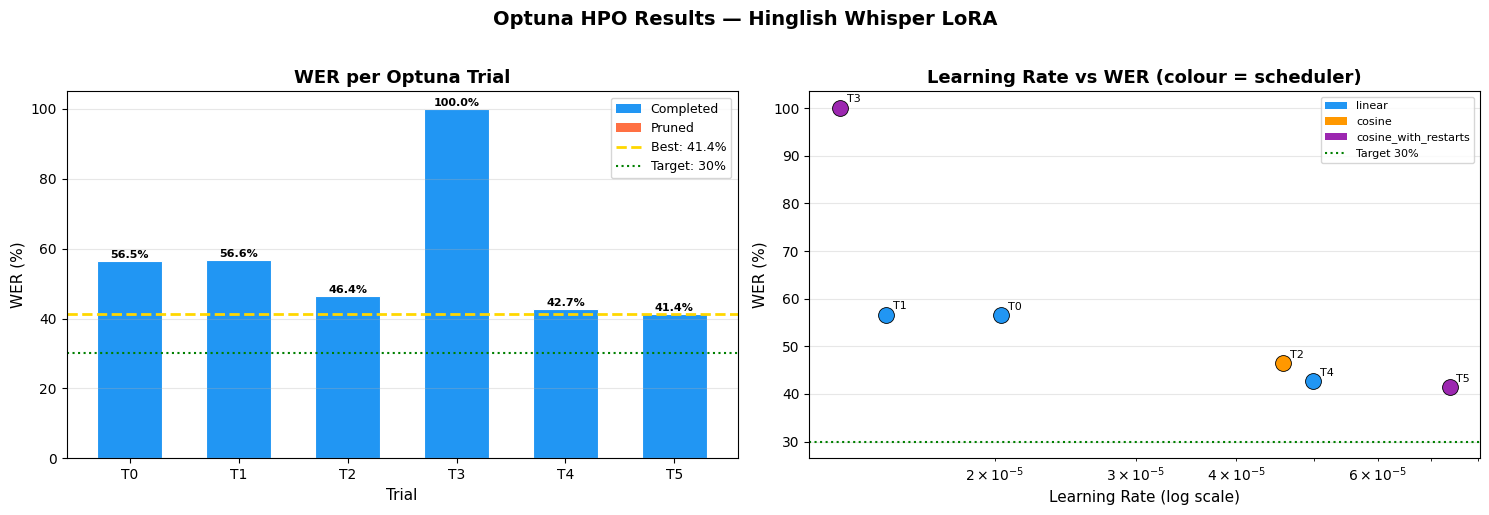

In [15]:
# ── Visualise HPO results ──────────────────────────────────────────────────────
completed = [t for t in study.trials if t.value is not None]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Plot 1: WER per trial (bar chart) ─────────────────────────────────────────
ax1 = axes[0]
colors = ["#2196F3" if t.state.name == "COMPLETE" else "#FF7043"
          for t in study.trials]
bar_vals = [t.value if t.value is not None else 0 for t in study.trials]
bars = ax1.bar(range(len(study.trials)), bar_vals,
               color=colors, edgecolor='white', linewidth=0.8, width=0.6)

ax1.axhline(study.best_value, color='gold',  linestyle='--', lw=2,
            label=f"Best: {study.best_value:.1f}%")
ax1.axhline(30,               color='green', linestyle=':',  lw=1.5,
            label="Target: 30%")
for bar, val, t in zip(bars, bar_vals, study.trials):
    lbl = f"{val:.1f}%" if val > 0 else "pruned"
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             lbl, ha='center', va='bottom', fontsize=8, fontweight='bold')

legend_patches = [
    Patch(facecolor='#2196F3', label='Completed'),
    Patch(facecolor='#FF7043', label='Pruned'),
]
ax1.legend(handles=legend_patches + ax1.get_lines(), fontsize=9)
ax1.set_xticks(range(len(study.trials)))
ax1.set_xticklabels([f"T{t.number}" for t in study.trials])
ax1.set_xlabel("Trial", fontsize=11)
ax1.set_ylabel("WER (%)", fontsize=11)
ax1.set_title("WER per Optuna Trial", fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# ── Plot 2: LR vs WER scatter (for completed trials) ──────────────────────────
ax2 = axes[1]
if len(completed) >= 2:
    lrs_  = [t.params["learning_rate"] for t in completed]
    wers_ = [t.value for t in completed]
    scheds = [t.params.get("scheduler","?") for t in completed]
    sched_color = {"linear":"#2196F3","cosine":"#FF9800","cosine_with_restarts":"#9C27B0"}

    for t in completed:
        c = sched_color.get(t.params.get("scheduler","?"), "grey")
        ax2.scatter(t.params["learning_rate"], t.value,
                    color=c, s=130, edgecolors='black', linewidth=0.6, zorder=5)
        ax2.annotate(f"T{t.number}",
                     (t.params["learning_rate"], t.value),
                     textcoords="offset points", xytext=(5, 4), fontsize=8)

    ax2.axhline(30, color='green', linestyle=':', lw=1.5, label="Target 30%")
    legend_sched = [Patch(facecolor=v, label=k) for k, v in sched_color.items()]
    ax2.legend(handles=legend_sched + ax2.get_lines(), fontsize=8)
    ax2.set_xscale('log')
    ax2.set_xlabel("Learning Rate (log scale)", fontsize=11)
    ax2.set_ylabel("WER (%)", fontsize=11)
    ax2.set_title("Learning Rate vs WER (colour = scheduler)", fontsize=13, fontweight='bold')
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, "Need ≥2 completed trials\nfor scatter plot",
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)

plt.suptitle("Optuna HPO Results — Hinglish Whisper LoRA",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
#PLOT_PATH = "/kaggle/working/optuna_results.png"
#plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
#print(f"✅ Plot saved → {PLOT_PATH}")

---
# 🟠 PHASE 3 — Final Training with Best Hyperparameters (10000 samples × 1000 steps)

Using the best params discovered by Optuna to run the full training.  
More samples + more steps → lower WER compared to each individual trial.

### 3A — Build Final Model with Best Params

In [16]:
print("📥 Building final model with best Optuna hyperparameters...")
print()
print(f"   lora_r         = {best_params['lora_r']}")
print(f"   lora_alpha     = {best_params['lora_alpha']}")
print(f"   lora_dropout   = {best_params['lora_dropout']}")
print(f"   target_modules = {TARGET_MODULES_MAP[best_params['target_modules']]}")
print(f"   learning_rate  = {best_params['learning_rate']:.2e}")
print(f"   warmup_steps   = {best_params['warmup_steps']}")
print(f"   weight_decay   = {best_params['weight_decay']:.4f}")
print(f"   scheduler      = {best_params['scheduler']}")
print()

model = build_trial_model(
    lora_r         = best_params["lora_r"],
    lora_alpha     = best_params["lora_alpha"],
    lora_dropout   = best_params["lora_dropout"],
    target_modules = TARGET_MODULES_MAP[best_params["target_modules"]],
)
model.print_trainable_parameters()

total_p    = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Parameter Summary:")
print(f"   Total      : {total_p/1e6:.1f}M")
print(f"   Trainable  : {trainable_p/1e6:.2f}M  ({100*trainable_p/total_p:.2f}%)")
print(f"   Frozen     : {(total_p-trainable_p)/1e6:.1f}M")
print("\n✅ Final model ready")

📥 Building final model with best Optuna hyperparameters...

   lora_r         = 32
   lora_alpha     = 64
   lora_dropout   = 0.2
   target_modules = ['q_proj', 'v_proj', 'fc1', 'fc2']
   learning_rate  = 7.37e-05
   warmup_steps   = 10
   weight_decay   = 0.0943
   scheduler      = cosine_with_restarts

trainable params: 25,165,824 || all params: 789,023,744 || trainable%: 3.1894888070694107

📊 Parameter Summary:
   Total      : 789.0M
   Trainable  : 25.17M  (3.19%)
   Frozen     : 763.9M

✅ Final model ready


### 3B — Final Training Loop (10000 samples × 1000 steps)

In [17]:
final_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)
final_loader   = DataLoader(
    final_train_dataset,
    batch_size  = TRIAL_BATCH_SIZE,
    shuffle     = True,
    collate_fn  = final_collator,
    num_workers = 2,
    pin_memory  = True,
)

optimizer_final = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = best_params["learning_rate"],
    weight_decay = best_params["weight_decay"],
)
scheduler_final = make_scheduler(
    best_params["scheduler"],
    optimizer_final,
    best_params["warmup_steps"],
    FINAL_MAX_STEPS,
)
scaler_final = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

# ── Training history (for plotting) ───────────────────────────────────────────
training_history = {"steps": [], "loss": [], "avg_loss": [], "learning_rate": []}

model.train()
step, total_loss = 0, 0.0

print(f"🚀 Final training run")
print(f"   Samples   : {FINAL_TRAIN_SIZE}")
print(f"   Max steps : {FINAL_MAX_STEPS}")
print(f"   Batch size: {TRIAL_BATCH_SIZE}  (eff. batch = {TRIAL_BATCH_SIZE})")
print(f"   LR        : {best_params['learning_rate']:.2e}")
print(f"   Scheduler : {best_params['scheduler']}\n")

while step < FINAL_MAX_STEPS:
    for batch in final_loader:
        if step >= FINAL_MAX_STEPS:
            break

        input_features = batch["input_features"].to(device).to(torch.float32)
        labels         = batch["labels"].to(device)
        optimizer_final.zero_grad()

        if scaler_final:
            with torch.cuda.amp.autocast():
                out  = model.base_model.model(input_features=input_features, labels=labels)
                loss = out.loss
            scaler_final.scale(loss).backward()
            scaler_final.unscale_(optimizer_final)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler_final.step(optimizer_final)
            scaler_final.update()
        else:
            out  = model.base_model.model(input_features=input_features, labels=labels)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer_final.step()

        scheduler_final.step()
        total_loss += loss.item()
        step       += 1

        if step % 10 == 0:
            avg    = total_loss / step
            lr_now = scheduler_final.get_last_lr()[0]
            training_history["steps"].append(step)
            training_history["loss"].append(loss.item())
            training_history["avg_loss"].append(avg)
            training_history["learning_rate"].append(lr_now)
            print(f"  Step {step:>4}/{FINAL_MAX_STEPS} | "
                  f"loss: {loss.item():.4f} | avg: {avg:.4f} | lr: {lr_now:.2e}")

print(f"\n✅ Final training complete! "
      f"Final avg loss: {total_loss/FINAL_MAX_STEPS:.4f}")

🚀 Final training run
   Samples   : 10000
   Max steps : 1000
   Batch size: 2  (eff. batch = 2)
   LR        : 7.37e-05
   Scheduler : cosine_with_restarts

  Step   10/1000 | loss: 2.4100 | avg: 2.8118 | lr: 7.37e-05
  Step   20/1000 | loss: 0.9986 | avg: 2.1669 | lr: 7.37e-05
  Step   30/1000 | loss: 1.1167 | avg: 1.8790 | lr: 7.35e-05
  Step   40/1000 | loss: 0.9577 | avg: 1.6846 | lr: 7.31e-05
  Step   50/1000 | loss: 0.7665 | avg: 1.5506 | lr: 7.26e-05
  Step   60/1000 | loss: 1.3610 | avg: 1.4557 | lr: 7.19e-05
  Step   70/1000 | loss: 0.3387 | avg: 1.3278 | lr: 7.11e-05
  Step   80/1000 | loss: 0.7476 | avg: 1.2428 | lr: 7.02e-05
  Step   90/1000 | loss: 0.4326 | avg: 1.1652 | lr: 6.91e-05
  Step  100/1000 | loss: 0.3766 | avg: 1.1056 | lr: 6.79e-05
  Step  110/1000 | loss: 0.5025 | avg: 1.0418 | lr: 6.66e-05
  Step  120/1000 | loss: 0.3043 | avg: 0.9915 | lr: 6.51e-05
  Step  130/1000 | loss: 1.0279 | avg: 0.9595 | lr: 6.36e-05
  Step  140/1000 | loss: 0.3899 | avg: 0.9177 | l

### 3C — Plot Final Training Progress

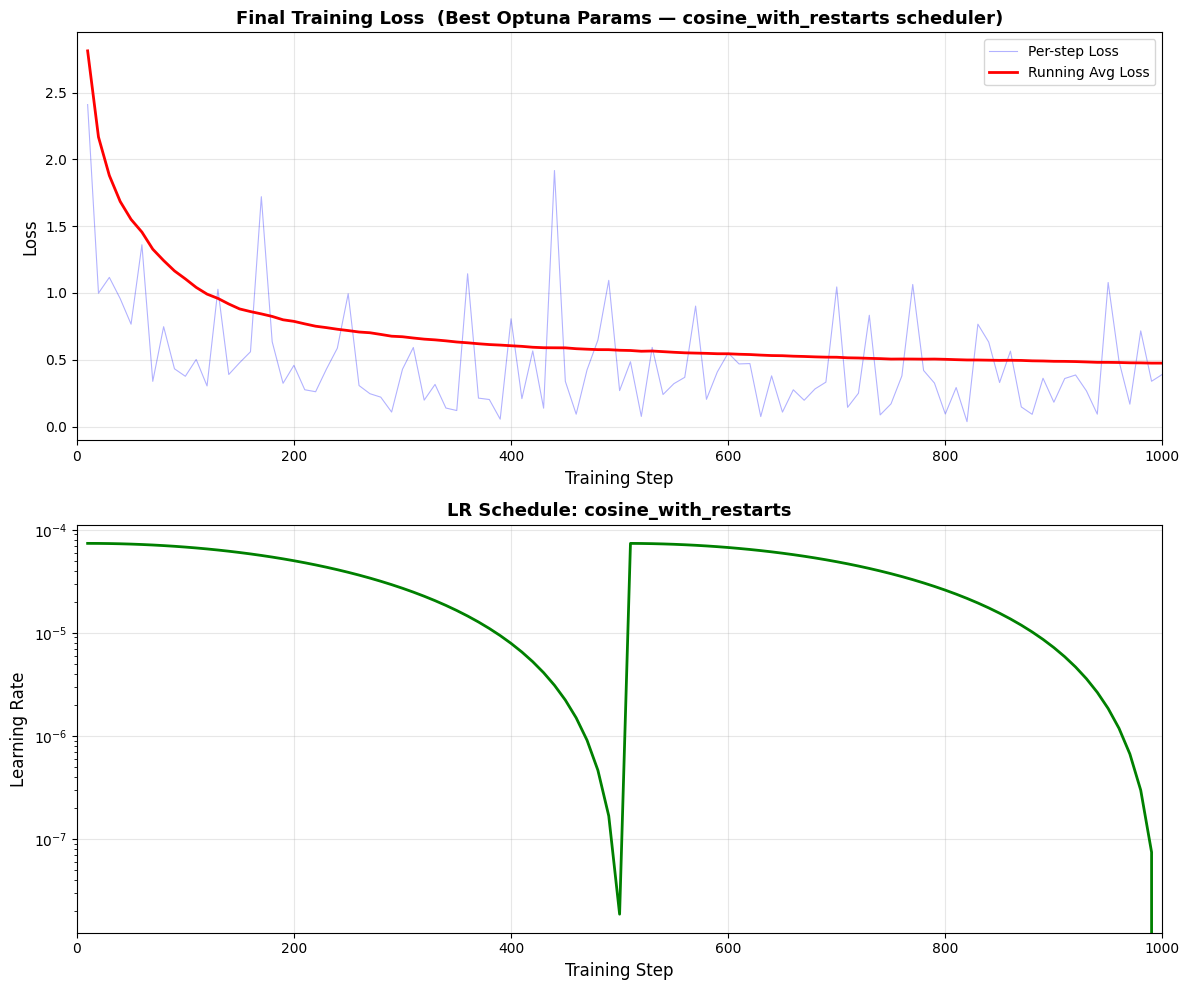


📊 Final Training Statistics:
   Initial Loss   : 2.4100
   Final Loss     : 0.3912
   Loss Reduction : 83.8%
   Peak LR        : 7.37e-05
   Final LR       : 0.00e+00


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

ax1 = axes[0]
ax1.plot(training_history["steps"], training_history["loss"],
         alpha=0.3, color='blue', label='Per-step Loss', linewidth=0.8)
ax1.plot(training_history["steps"], training_history["avg_loss"],
         color='red', label='Running Avg Loss', linewidth=2)
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title(f'Final Training Loss  (Best Optuna Params — {best_params["scheduler"]} scheduler)',
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, FINAL_MAX_STEPS)

ax2 = axes[1]
ax2.plot(training_history["steps"], training_history["learning_rate"],
         color='green', linewidth=2)
ax2.set_xlabel('Training Step', fontsize=12)
ax2.set_ylabel('Learning Rate', fontsize=12)
ax2.set_title(f'LR Schedule: {best_params["scheduler"]}', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, FINAL_MAX_STEPS)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

losses_ = training_history["loss"]
lrs_    = training_history["learning_rate"]
print("\n📊 Final Training Statistics:")
print(f"   Initial Loss   : {losses_[0]:.4f}")
print(f"   Final Loss     : {losses_[-1]:.4f}")
print(f"   Loss Reduction : {((losses_[0]-losses_[-1])/losses_[0]*100):.1f}%")
print(f"   Peak LR        : {max(lrs_):.2e}")
print(f"   Final LR       : {lrs_[-1]:.2e}")

### 3D — Save Fine-tuned Model

In [19]:
SAVE_PATH = "./whisper-medium-hinglish-lora-final"

model.save_pretrained(SAVE_PATH)
processor.save_pretrained(SAVE_PATH)

print(f"✅ Fine-tuned model saved to: {SAVE_PATH}")
print(f"   Files: {os.listdir(SAVE_PATH)}")

✅ Fine-tuned model saved to: ./whisper-medium-hinglish-lora-final
   Files: ['README.md', 'preprocessor_config.json', 'normalizer.json', 'vocab.json', 'merges.txt', 'adapter_model.safetensors', 'added_tokens.json', 'adapter_config.json', 'special_tokens_map.json', 'tokenizer_config.json']


---
# 🔴 PHASE 4 — Evaluate Fine-tuned Model on Same 10 Samples

In [20]:
print("📥 Loading fine-tuned model for evaluation...")

# Load base + LoRA weights, then merge for fast inference
base_model_ft   = WhisperForConditionalGeneration.from_pretrained(
    MODEL_NAME, torch_dtype=dtype, low_cpu_mem_usage=True
)
finetuned_model = PeftModel.from_pretrained(base_model_ft, SAVE_PATH)
finetuned_model = finetuned_model.merge_and_unload()   # fuse LoRA into base weights
finetuned_model.to(device)
finetuned_model.eval()

ft_processor = WhisperProcessor.from_pretrained(SAVE_PATH, language=LANGUAGE, task=TASK)

print("✅ Fine-tuned model loaded. Running inference on 10 samples...")
preds_finetuned = transcribe_samples(
    finetuned_model, test_samples, processor=ft_processor, use_pipeline=False
)

wer_finetuned, cer_finetuned = print_results_table(
    "whisper-medium (LoRA Optuna best-params)", preds_finetuned, REFERENCES
)

📥 Loading fine-tuned model for evaluation...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


✅ Fine-tuned model loaded. Running inference on 10 samples...

  Model : whisper-medium (LoRA Optuna best-params)
  WER   : 47.97%   |   CER   : 41.36%
  Gen   : repetition_penalty=1.2  no_repeat_ngram_size=3
#    REFERENCE                                     PREDICTION                                   
------------------------------------------------------------------------------------------------
0    लिबर ऑफिस impress में एक प्रस्तुति document…  libreoffice impress में एक प्रस्तुती docume… 
1    इस tutorial में हम impress window के भागों …  इस tutorial में हम impress window के भागों … 
2    यहाँ हम अपने ऑपरेटिंग सिस्टम के रूप में gnu…  यहाँ हम अपने operating system के रूप में jn… 
3    चलिए अपनी प्रस्तुति प्रेजैटेशन sample impre…  चलिए अपनी प्रस्तुति sample impressed open क… 
4    चलिए देखते हैं कि screen पर क्या क्या है      चलिए देखते हैं कि screen पर क्या क्षा है     
5    मध्य में हम खाली जगह देखते है जोकि workspac…  मध्य में हम खाली जगह देखते हैं               
6    जैसे कि आप

# 🔴 PHASE 5 — Calculate WER / CER over 100 samples

In [21]:
print("✅ Running inference on 100 samples with fine-tuned model...")

preds_finetuned_100 = transcribe_samples(
    finetuned_model, test_data, processor=ft_processor, use_pipeline=False
)

wer_finetuned_100, cer_finetuned_100 = print_results_table(
    "whisper-medium (LoRA Optuna best-params)",
    preds_finetuned_100,
    refs_data
)

✅ Running inference on 100 samples with fine-tuned model...

  Model : whisper-medium (LoRA Optuna best-params)
  WER   : 36.46%   |   CER   : 30.94%
  Gen   : repetition_penalty=1.2  no_repeat_ngram_size=3
#    REFERENCE                                     PREDICTION                                   
------------------------------------------------------------------------------------------------
0    लिबर ऑफिस impress में एक प्रस्तुति document…  libreoffice impress में एक प्रस्तुती docume… 
1    इस tutorial में हम impress window के भागों …  इस tutorial में हम impress window के भागों … 
2    यहाँ हम अपने ऑपरेटिंग सिस्टम के रूप में gnu…  यहाँ हम अपने operating system के रूप में jn… 
3    चलिए अपनी प्रस्तुति प्रेजैटेशन sample impre…  चलिए अपनी प्रस्तुति sample impressed open क… 
4    चलिए देखते हैं कि screen पर क्या क्या है      चलिए देखते हैं कि screen पर क्या क्षा है     
5    मध्य में हम खाली जगह देखते है जोकि workspac…  मध्य में हम खाली जगह देखते हैं               
6    जैसे कि आप द

---
# 📊 FINAL COMPARISON — Fine-Tuned vs Baselines

In [22]:
results = {
    "Model": [
        "openai/whisper-medium (baseline)",
        "whisper-medium (LoRA + Optuna best-params)",
    ],
    "WER (%)": [wer_medium_100, wer_finetuned_100],
    "CER (%)": [cer_medium_100, cer_finetuned_100],
}

df_results = pd.DataFrame(results)
df_results["WER Δ vs baseline"] = [
    "—",
    f"{wer_finetuned_100 - wer_medium_100:+.2f}%",
]
df_results["CER Δ vs baseline"] = [
    "—",
    f"{cer_finetuned_100 - cer_medium_100:+.2f}%",
]

print("\n" + "="*80)
print("  📊  FINAL RESULTS SUMMARY  (100-sample evaluation)")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

valid_wers = [(i, w) for i, w in enumerate(df_results["WER (%)"]) if w is not None]
best_idx, best_wer_val = min(valid_wers, key=lambda x: x[1])
print(f"\n🏆 Best WER : {best_wer_val:.2f}% — {df_results.loc[best_idx, 'Model']}")




  📊  FINAL RESULTS SUMMARY  (100-sample evaluation)
                                     Model  WER (%)  CER (%) WER Δ vs baseline CER Δ vs baseline
          openai/whisper-medium (baseline)    70.62    54.92                 —                 —
whisper-medium (LoRA + Optuna best-params)    36.46    30.94           -34.16%           -23.98%

🏆 Best WER : 36.46% — whisper-medium (LoRA + Optuna best-params)


---
# 🔍 PHASE 5B — Error Analysis (100-sample evaluation)

Detailed error analysis to understand failure patterns, error types, and improvement areas.


In [23]:
import re
from collections import Counter, defaultdict
from jiwer import compute_measures

print("="*80)
print("🔍 ERROR ANALYSIS — 100 Sample Evaluation")
print("="*80)

# ── Helper function to detect language (Hindi vs English) ────────────────────
def detect_language(word):
    """Simple heuristic: Devanagari script vs ASCII"""
    # Check if word contains Devanagari characters (Unicode range: 0900-097F)
    has_devanagari = bool(re.search(r'[\u0900-\u097F]', word))
    # Check if word contains only ASCII letters/numbers
    is_ascii = bool(re.match(r'^[a-zA-Z0-9\s\-.,;:!?()]+$', word))
    
    if has_devanagari:
        return "Hindi"
    elif is_ascii and len(word.strip()) > 0:
        return "English"
    else:
        return "Mixed/Other"

def split_into_words(text):
    """Split text into words, preserving punctuation"""
    return re.findall(r'\S+', text.lower())

# ── 1. Error Type Breakdown (Substitutions, Insertions, Deletions) ───────────
print("\n" + "="*80)
print("1️⃣  ERROR TYPE BREAKDOWN")
print("="*80)

# Baseline error breakdown
measures_baseline = compute_measures(refs_data, preds_medium_100)
subs_baseline = measures_baseline['substitutions']
ins_baseline = measures_baseline['insertions']
dels_baseline = measures_baseline['deletions']
hits_baseline = measures_baseline['hits']
total_words_baseline = subs_baseline + ins_baseline + dels_baseline + hits_baseline

# Fine-tuned error breakdown
measures_finetuned = compute_measures(refs_data, preds_finetuned_100)
subs_finetuned = measures_finetuned['substitutions']
ins_finetuned = measures_finetuned['insertions']
dels_finetuned = measures_finetuned['deletions']
hits_finetuned = measures_finetuned['hits']
total_words_finetuned = subs_finetuned + ins_finetuned + dels_finetuned + hits_finetuned

print(f"\n📊 Baseline Model (openai/whisper-medium):")
print(f"   Substitutions: {subs_baseline} ({subs_baseline/total_words_baseline*100:.1f}%)")
print(f"   Insertions:    {ins_baseline} ({ins_baseline/total_words_baseline*100:.1f}%)")
print(f"   Deletions:     {dels_baseline} ({dels_baseline/total_words_baseline*100:.1f}%)")
print(f"   Correct:       {hits_baseline} ({hits_baseline/total_words_baseline*100:.1f}%)")
print(f"   Total words:   {total_words_baseline}")

print(f"\n📊 Fine-tuned Model (LoRA + Optuna):")
print(f"   Substitutions: {subs_finetuned} ({subs_finetuned/total_words_finetuned*100:.1f}%)")
print(f"   Insertions:    {ins_finetuned} ({ins_finetuned/total_words_finetuned*100:.1f}%)")
print(f"   Deletions:     {dels_finetuned} ({dels_finetuned/total_words_finetuned*100:.1f}%)")
print(f"   Correct:       {hits_finetuned} ({hits_finetuned/total_words_finetuned*100:.1f}%)")
print(f"   Total words:   {total_words_finetuned}")

print(f"\n📈 Improvement:")
print(f"   Substitutions: {subs_baseline - subs_finetuned:+d} ({(subs_baseline-subs_finetuned)/subs_baseline*100:.1f}% reduction)")
print(f"   Insertions:    {ins_baseline - ins_finetuned:+d} ({(ins_baseline-ins_finetuned)/ins_baseline*100:.1f}% reduction)")
print(f"   Deletions:     {dels_baseline - dels_finetuned:+d} ({(dels_baseline-dels_finetuned)/dels_baseline*100:.1f}% reduction)")

# ── 2. Per-Sample Error Analysis ─────────────────────────────────────────────
print("\n" + "="*80)
print("2️⃣  PER-SAMPLE ERROR ANALYSIS")
print("="*80)

sample_errors_baseline = []
sample_errors_finetuned = []

for i, (ref, pred_b, pred_f) in enumerate(zip(refs_data, preds_medium_100, preds_finetuned_100)):
    # Calculate WER for each sample
    measures_b = compute_measures([ref], [pred_b])
    measures_f = compute_measures([ref], [pred_f])
    
    wer_b = (measures_b['substitutions'] + measures_b['insertions'] + measures_b['deletions']) / max(len(ref.split()), 1) * 100
    wer_f = (measures_f['substitutions'] + measures_f['insertions'] + measures_f['deletions']) / max(len(ref.split()), 1) * 100
    
    sample_errors_baseline.append((i, wer_b, ref, pred_b))
    sample_errors_finetuned.append((i, wer_f, ref, pred_f))

# Sort by error rate (worst first)
sample_errors_baseline.sort(key=lambda x: x[1], reverse=True)
sample_errors_finetuned.sort(key=lambda x: x[1], reverse=True)

print(f"\n🔴 Top 10 Worst-Performing Samples (Baseline):")
print("-" * 80)
for idx, (i, wer, ref, pred) in enumerate(sample_errors_baseline[:10]):
    ref_short = ref[:60] + "…" if len(ref) > 60 else ref
    pred_short = pred[:60] + "…" if len(pred) > 60 else pred
    print(f"{idx+1:2d}. Sample {i:3d} | WER: {wer:6.2f}%")
    print(f"    Ref:  {ref_short}")
    print(f"    Pred: {pred_short}")
    print()

print(f"\n🟢 Top 10 Worst-Performing Samples (Fine-tuned):")
print("-" * 80)
for idx, (i, wer, ref, pred) in enumerate(sample_errors_finetuned[:10]):
    ref_short = ref[:60] + "…" if len(ref) > 60 else ref
    pred_short = pred[:60] + "…" if len(pred) > 60 else pred
    print(f"{idx+1:2d}. Sample {i:3d} | WER: {wer:6.2f}%")
    print(f"    Ref:  {ref_short}")
    print(f"    Pred: {pred_short}")
    print()

# ── 3. Language-Specific Error Analysis (Hindi vs English) ──────────────────
print("\n" + "="*80)
print("3️⃣  LANGUAGE-SPECIFIC ERROR ANALYSIS (Hindi vs English)")
print("="*80)

def analyze_language_errors(refs, preds):
    """Analyze errors by language (Hindi vs English words)"""
    hindi_errors = {"subs": 0, "ins": 0, "dels": 0, "total": 0}
    english_errors = {"subs": 0, "ins": 0, "dels": 0, "total": 0}
    
    for ref, pred in zip(refs, preds):
        ref_words = split_into_words(ref)
        pred_words = split_into_words(pred)
        
        # Simple alignment-based error counting
        # For each word in reference, check if it appears in prediction
        for word in ref_words:
            lang = detect_language(word)
            if lang == "Hindi":
                hindi_errors["total"] += 1
                if word not in pred_words:
                    hindi_errors["dels"] += 1
            elif lang == "English":
                english_errors["total"] += 1
                if word not in pred_words:
                    english_errors["dels"] += 1
        
        # Check for insertions (words in pred but not in ref)
        for word in pred_words:
            lang = detect_language(word)
            if word not in ref_words:
                if lang == "Hindi":
                    hindi_errors["ins"] += 1
                elif lang == "English":
                    english_errors["ins"] += 1
    
    return hindi_errors, english_errors

hindi_err_b, eng_err_b = analyze_language_errors(refs_data, preds_medium_100)
hindi_err_f, eng_err_f = analyze_language_errors(refs_data, preds_finetuned_100)

print(f"\n📊 Baseline Model:")
print(f"   Hindi words:  Total={hindi_err_b['total']}, Errors={hindi_err_b['dels']+hindi_err_b['ins']}, "
      f"Error Rate={(hindi_err_b['dels']+hindi_err_b['ins'])/max(hindi_err_b['total'],1)*100:.1f}%")
print(f"   English words: Total={eng_err_b['total']}, Errors={eng_err_b['dels']+eng_err_b['ins']}, "
      f"Error Rate={(eng_err_b['dels']+eng_err_b['ins'])/max(eng_err_b['total'],1)*100:.1f}%")

print(f"\n📊 Fine-tuned Model:")
print(f"   Hindi words:  Total={hindi_err_f['total']}, Errors={hindi_err_f['dels']+hindi_err_f['ins']}, "
      f"Error Rate={(hindi_err_f['dels']+hindi_err_f['ins'])/max(hindi_err_f['total'],1)*100:.1f}%")
print(f"   English words: Total={eng_err_f['total']}, Errors={eng_err_f['dels']+eng_err_f['ins']}, "
      f"Error Rate={(eng_err_f['dels']+eng_err_f['ins'])/max(eng_err_f['total'],1)*100:.1f}%")

# ── 4. Common Error Patterns ─────────────────────────────────────────────────
print("\n" + "="*80)
print("4️⃣  COMMON ERROR PATTERNS")
print("="*80)

# Find samples with significant improvement
improvements = []
for i in range(len(refs_data)):
    measures_b = compute_measures([refs_data[i]], [preds_medium_100[i]])
    measures_f = compute_measures([refs_data[i]], [preds_finetuned_100[i]])
    
    wer_b = (measures_b['substitutions'] + measures_b['insertions'] + measures_b['deletions']) / max(len(refs_data[i].split()), 1) * 100
    wer_f = (measures_f['substitutions'] + measures_f['insertions'] + measures_f['deletions']) / max(len(refs_data[i].split()), 1) * 100
    
    improvement = wer_b - wer_f
    if improvement > 20:  # Significant improvement (>20% WER reduction)
        improvements.append((i, improvement, wer_b, wer_f, refs_data[i], preds_medium_100[i], preds_finetuned_100[i]))

improvements.sort(key=lambda x: x[1], reverse=True)

print(f"\n✅ Top 5 Samples with Best Improvement:")
print("-" * 80)
for idx, (i, imp, wer_b, wer_f, ref, pred_b, pred_f) in enumerate(improvements[:5]):
    print(f"{idx+1}. Sample {i} | Improvement: {imp:.1f}% (WER: {wer_b:.1f}% → {wer_f:.1f}%)")
    print(f"   Reference:  {ref[:70]}…" if len(ref) > 70 else f"   Reference:  {ref}")
    print(f"   Baseline:   {pred_b[:70]}…" if len(pred_b) > 70 else f"   Baseline:   {pred_b}")
    print(f"   Fine-tuned: {pred_f[:70]}…" if len(pred_f) > 70 else f"   Fine-tuned: {pred_f}")
    print()

# ── 5. Summary Statistics ──────────────────────────────────────────────────────
print("\n" + "="*80)
print("5️⃣  ERROR ANALYSIS SUMMARY")
print("="*80)

avg_wer_baseline = sum([x[1] for x in sample_errors_baseline]) / len(sample_errors_baseline)
avg_wer_finetuned = sum([x[1] for x in sample_errors_finetuned]) / len(sample_errors_finetuned)

perfect_baseline = sum([1 for x in sample_errors_baseline if x[1] == 0])
perfect_finetuned = sum([1 for x in sample_errors_finetuned if x[1] == 0])

print(f"\n📊 Summary Statistics:")
print(f"   Average WER per sample:")
print(f"      Baseline:   {avg_wer_baseline:.2f}%")
print(f"      Fine-tuned: {avg_wer_finetuned:.2f}%")
print(f"      Improvement: {avg_wer_baseline - avg_wer_finetuned:.2f}%")
print(f"\n   Perfect transcriptions (WER = 0%):")
print(f"      Baseline:   {perfect_baseline}/100 ({perfect_baseline}%)")
print(f"      Fine-tuned: {perfect_finetuned}/100 ({perfect_finetuned}%)")
print(f"\n   Most common error type:")
print(f"      Baseline:   Substitutions ({subs_baseline/total_words_baseline*100:.1f}% of words)")
print(f"      Fine-tuned: Substitutions ({subs_finetuned/total_words_finetuned*100:.1f}% of words)")

print("\n" + "="*80)
print("✅ Error analysis complete!")
print("="*80)


🔍 ERROR ANALYSIS — 100 Sample Evaluation

1️⃣  ERROR TYPE BREAKDOWN

📊 Baseline Model (openai/whisper-medium):
   Substitutions: 576 (43.7%)
   Insertions:    62 (4.7%)
   Deletions:     249 (18.9%)
   Correct:       431 (32.7%)
   Total words:   1318

📊 Fine-tuned Model (LoRA + Optuna):
   Substitutions: 200 (15.6%)
   Insertions:    22 (1.7%)
   Deletions:     236 (18.5%)
   Correct:       820 (64.2%)
   Total words:   1278

📈 Improvement:
   Substitutions: +376 (65.3% reduction)
   Insertions:    +40 (64.5% reduction)
   Deletions:     +13 (5.2% reduction)

2️⃣  PER-SAMPLE ERROR ANALYSIS

🔴 Top 10 Worst-Performing Samples (Baseline):
--------------------------------------------------------------------------------
 1. Sample  86 | WER: 177.78%
    Ref:  stdlib h header file निम्न को परिभाषित करता है
    Pred:  STDlib.h header file निम्न को परीभासुत करता है, Numeric Con…

 2. Sample   7 | WER: 160.00%
    Ref:  फिलहाल normal टैब चुनित हैं
    Pred:  जिने वीव बतर्स कहते हैं. पिढाल नॉरम

## 🔍 Per-Sample Breakdown — All Models (100 samples)

In [24]:
print("\n📋 PER-SAMPLE COMPARISON (100 samples inference)")
print("=" * 148)
print(f"{'#':<3} {'REFERENCE':<38} {'whisper-medium':<35} "
      f"{'medium-hindi':<35} {'LoRA Optuna':<35}")
print("-" * 148)

for i in range(10):
    ref = REFERENCES[i][:35]        + '…' if len(REFERENCES[i])    > 36 else REFERENCES[i]
    pm  = preds_medium_100[i][:33]      + '…' if len(preds_medium_100[i])  > 34 else preds_medium_100[i]
    pft = preds_finetuned_100[i][:33]   + '…' if len(preds_finetuned_100[i]) > 34 else preds_finetuned_100[i]
    print(f"{i:<3} {ref:<38} {pm:<35} {pft:<35}")

print("-" * 148)
print(f"{'':3} {'':38} "
      f"WER:{wer_medium_100}% CER:{cer_medium_100}%   "
      f"WER:{wer_finetuned_100}% CER:{cer_finetuned_100}%")


📋 PER-SAMPLE COMPARISON (100 samples inference)
#   REFERENCE                              whisper-medium                      medium-hindi                        LoRA Optuna                        
----------------------------------------------------------------------------------------------------------------------------------------------------
0   लिबर ऑफिस impress में एक प्रस्तुति …    लिबर आफस् इम्प्लेस में एक प्रस्त…  libreoffice impress में एक प्रस्त… 
1   इस tutorial में हम impress window क…    इस चीटुरल में हम इंप्रैस विन्डो …  इस tutorial में हम impress window… 
2   यहाँ हम अपने ऑपरेटिंग सिस्टम के रूप…    यहां हम अपने Operating System के…  यहाँ हम अपने operating system के … 
3   चलिए अपनी प्रस्तुति प्रेजैटेशन samp…    जब इसकारे किना प्रस्तुती सैमपल ए…  चलिए अपनी प्रस्तुति sample impres… 
4   चलिए देखते हैं कि screen पर क्या क्…    जब देते हैं कि स्कॉरीन पर क्या क…  चलिए देखते हैं कि screen पर क्या … 
5   मध्य में हम खाली जगह देखते है जोकि …    पराइक्यूंगे को लिए ज़िन्माची तो 